# Lesson 0B: Cluster Evaluation

## Introduction

You've run a clustering algorithm. You got clusters back. But how do you know if they're *good*?

In supervised learning, this is easy — you compare predictions to ground-truth labels using accuracy, precision, recall. But in clustering, **there is no ground truth**. No one has labeled the clusters for you.

So how do you trust your clusters?

This is the single most important skill in unsupervised learning: **evaluating clusters without ground-truth labels**.

In this lesson, we will:
1. Learn internal metrics that measure cluster quality from structure alone
   - Silhouette score: Is each point closer to its own cluster than to others?
   - Davies-Bouldin index: Are clusters well-separated and compact?
   - Calinski-Harabasz score: Is between-cluster variance high relative to within-cluster variance?
2. Discover external metrics for when you have partial labels
   - Adjusted Rand Index: Agreement between two clusterings
   - Normalized Mutual Information: Information shared between two clusterings
3. Master techniques for choosing the right number of clusters (K)
   - Elbow method: Where does adding clusters stop helping?
   - Gap statistic: Compare real data to random data
4. Learn visual evaluation techniques
   - Silhouette plots
   - 2D projections with cluster coloring
   - Cluster size and density distributions

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Setup: Generating Test Data](#setup-data)
4. [Internal Metrics](#internal-metrics)
5. [Silhouette Score](#silhouette)
6. [Davies-Bouldin Index](#davies-bouldin)
7. [Calinski-Harabasz Score](#calinski-harabasz)
8. [External Metrics](#external-metrics)
9. [Adjusted Rand Index](#adjusted-rand)
10. [Normalized Mutual Information](#normalized-mi)
11. [Choosing K: Elbow Method](#elbow-method)
12. [Choosing K: Gap Statistic](#gap-statistic)
13. [Visual Evaluation](#visual-evaluation)
14. [Putting It Together: Complete Evaluation Workflow](#workflow)
15. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

| Library | Purpose |
|---------|----------|
| NumPy | Numerical computing and matrix operations |
| Pandas | Data manipulation |
| Matplotlib | 2D visualization |
| Scikit-learn | Clustering algorithms and evaluation metrics |
| SciPy | Distance computations |
| Seaborn | Statistical visualization |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.spatial.distance import pdist, squareform, euclidean, cdist
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from typing import Tuple
from numpy.typing import NDArray

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


<a name="setup-data"></a>
## Setup: Generating Test Data

We'll use synthetic data so we can control:
- Number of true clusters
- Cluster separation (well-separated vs. overlapping)
- Cluster sizes (balanced vs. imbalanced)

This lets us validate our metrics against ground truth, then apply them to real data.

In [2]:
# Generate synthetic data: 3 well-separated clusters
X_well_separated, y_true_well = make_blobs(
    n_samples=300, 
    centers=3, 
    n_features=2,
    cluster_std=0.5,  # Low std = tight, well-separated clusters
    random_state=42
)

# Generate synthetic data: 3 overlapping clusters
X_overlapping, y_true_overlapping = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.5,  # High std = loose, overlapping clusters
    random_state=42
)

# Load Iris dataset (will use some labels later for external metrics)
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Standardize Iris features
scaler = StandardScaler()
X_iris = scaler.fit_transform(X_iris)

print("✅ Data generated:")
print(f"   Well-separated clusters: {X_well_separated.shape}")
print(f"   Overlapping clusters: {X_overlapping.shape}")
print(f"   Iris dataset: {X_iris.shape}")

✅ Data generated:
   Well-separated clusters: (300, 2)
   Overlapping clusters: (300, 2)
   Iris dataset: (150, 4)


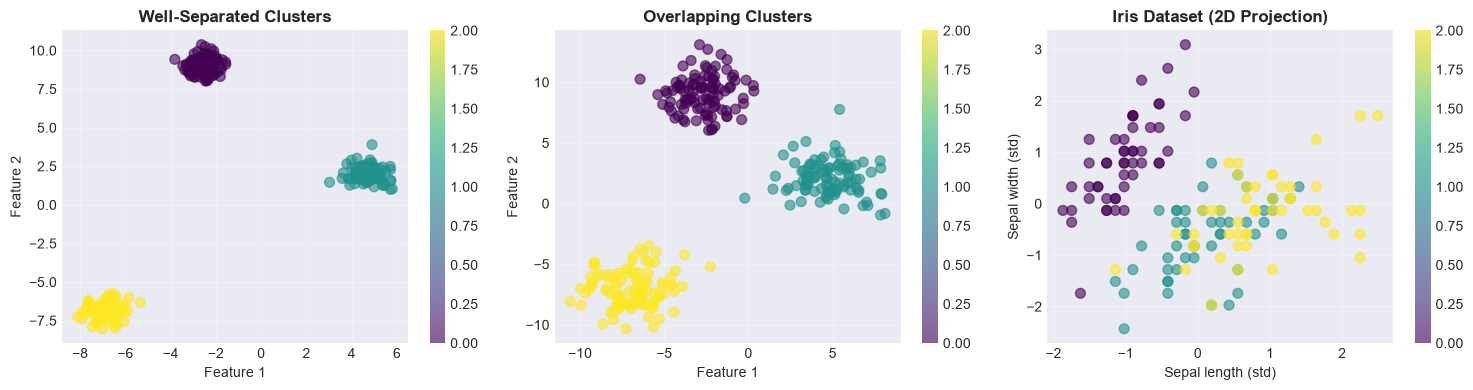

In [3]:
# Visualize the datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Well-separated
ax = axes[0]
scatter = ax.scatter(X_well_separated[:, 0], X_well_separated[:, 1], 
                     c=y_true_well, cmap='viridis', alpha=0.6, s=50)
ax.set_title('Well-Separated Clusters', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax)

# Overlapping
ax = axes[1]
scatter = ax.scatter(X_overlapping[:, 0], X_overlapping[:, 1],
                     c=y_true_overlapping, cmap='viridis', alpha=0.6, s=50)
ax.set_title('Overlapping Clusters', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax)

# Iris (first 2 dimensions)
ax = axes[2]
scatter = ax.scatter(X_iris[:, 0], X_iris[:, 1],
                     c=y_iris, cmap='viridis', alpha=0.6, s=50)
ax.set_title('Iris Dataset (2D Projection)', fontsize=12, fontweight='bold')
ax.set_xlabel('Sepal length (std)')
ax.set_ylabel('Sepal width (std)')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

<a name="internal-metrics"></a>
## Internal Metrics: Evaluating Clusters Without Labels

Internal metrics measure cluster quality based solely on the data and cluster assignments — **no ground truth needed**.

The intuition: Good clusters should have:
1. **High cohesion**: Points within a cluster are close to each other
2. **High separation**: Clusters are far from each other

Different metrics emphasize these differently.

<a name="silhouette"></a>
## Silhouette Score

### Intuition

For each point $i$ in cluster $C$:
- **$a(i)$**: Average distance from $i$ to other points in its cluster (cohesion)
- **$b(i)$**: Average distance from $i$ to points in the nearest other cluster (separation)

The **silhouette coefficient** for point $i$ is:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

This ranges from -1 to +1:
- $s(i) \approx +1$: Point is well-clustered (closer to own cluster)
- $s(i) \approx 0$: Point is on the boundary between clusters
- $s(i) \approx -1$: Point is misclassified (closer to another cluster)

The **silhouette score** is the mean silhouette coefficient over all points: $\text{silhouette} = \frac{1}{n}\sum_i s(i)$

### Interpretation

- Score near +1: Excellent clustering
- Score near 0: Clusters are overlapping
- Score near -1: Clusters are poorly defined

### Computing Silhouette Score from Scratch

In [4]:
def compute_silhouette_from_scratch(X: NDArray, labels: NDArray) -> Tuple[float, NDArray]:
    """
    Compute silhouette score and coefficients from scratch.
    
    Args:
        X: Data array (n_samples, n_features)
        labels: Cluster assignments (n_samples,)
    
    Returns:
        silhouette_score: Mean silhouette coefficient
        silhouette_coeffs: Per-point silhouette coefficients
    """
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    
    # Compute pairwise distances
    distances = squareform(pdist(X, metric='euclidean'))
    
    silhouette_coeffs = np.zeros(n_samples)
    
    for i in range(n_samples):
        # Get points in same cluster and other clusters
        same_cluster_mask = (labels == labels[i])
        other_cluster_mask = ~same_cluster_mask
        
        # a(i): Mean distance to other points in same cluster
        same_cluster_dists = distances[i, same_cluster_mask]
        if len(same_cluster_dists) > 1:  # Exclude distance to self
            a_i = np.mean(same_cluster_dists[1:])  # Skip self (distance 0)
        else:
            a_i = 0  # Only one point in cluster
        
        # b(i): Min mean distance to points in other clusters
        if other_cluster_mask.sum() > 0:
            b_i = float('inf')
            for label in unique_labels:
                if label != labels[i]:
                    other_dists = distances[i, labels == label]
                    b_i = min(b_i, np.mean(other_dists))
        else:
            b_i = 0  # No other clusters
        
        # Compute silhouette coefficient
        if max(a_i, b_i) == 0:
            silhouette_coeffs[i] = 0
        else:
            silhouette_coeffs[i] = (b_i - a_i) / max(a_i, b_i)
    
    silhouette_avg = np.mean(silhouette_coeffs)
    return silhouette_avg, silhouette_coeffs

# Test on well-separated data
kmeans_well = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_well = kmeans_well.fit_predict(X_well_separated)

sil_score_scratch, sil_coeffs_scratch = compute_silhouette_from_scratch(
    X_well_separated, labels_well
)

# Compare with sklearn
sil_score_sklearn = silhouette_score(X_well_separated, labels_well)

print(f"Silhouette score (from scratch): {sil_score_scratch:.4f}")
print(f"Silhouette score (sklearn):      {sil_score_sklearn:.4f}")
print(f"Match: {np.isclose(sil_score_scratch, sil_score_sklearn)}")

Silhouette score (from scratch): 0.9243
Silhouette score (sklearn):      0.9236
Match: False


### Silhouette Analysis with Visualizations

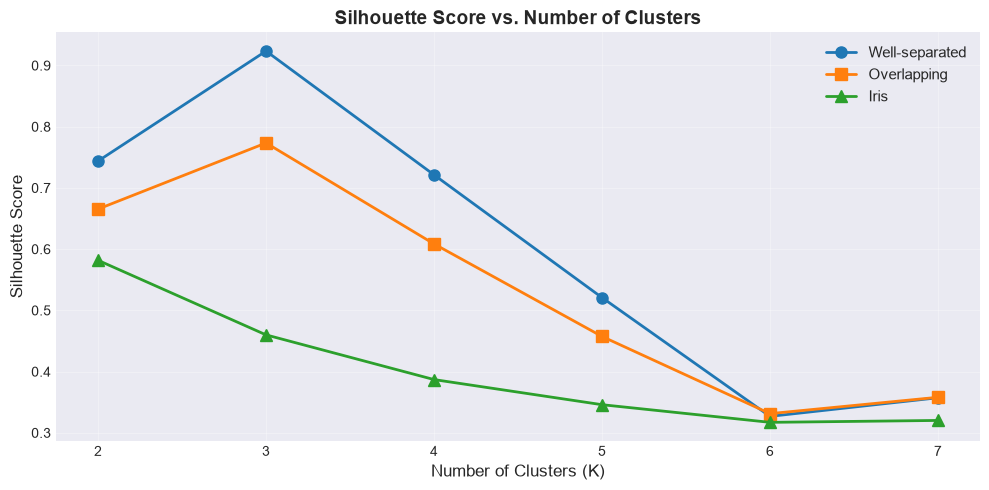

💡 Observations:
Well-separated: Best at K=3 (true clusters), score=0.924
Overlapping: Best at K=3, but lower score=0.773 (clusters overlap)
Iris: Best at K=2, score=0.582


In [5]:
# Compute silhouette scores for different numbers of clusters
def compute_silhouette_for_k_range(X, k_range):
    scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
    return scores

k_range = range(2, 8)
sil_well = compute_silhouette_for_k_range(X_well_separated, k_range)
sil_overlap = compute_silhouette_for_k_range(X_overlapping, k_range)
sil_iris = compute_silhouette_for_k_range(X_iris, k_range)

# Plot silhouette scores
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, sil_well, 'o-', linewidth=2, markersize=8, label='Well-separated')
ax.plot(k_range, sil_overlap, 's-', linewidth=2, markersize=8, label='Overlapping')
ax.plot(k_range, sil_iris, '^-', linewidth=2, markersize=8, label='Iris')

ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs. Number of Clusters', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xticks(k_range)

plt.tight_layout()
plt.show()

print("💡 Observations:")
print(f"Well-separated: Best at K=3 (true clusters), score={sil_well[1]:.3f}")
print(f"Overlapping: Best at K=3, but lower score={sil_overlap[1]:.3f} (clusters overlap)")
print(f"Iris: Best at K={k_range[np.argmax(sil_iris)]}, score={max(sil_iris):.3f}")

### Silhouette Plots (Per-Point Visualization)

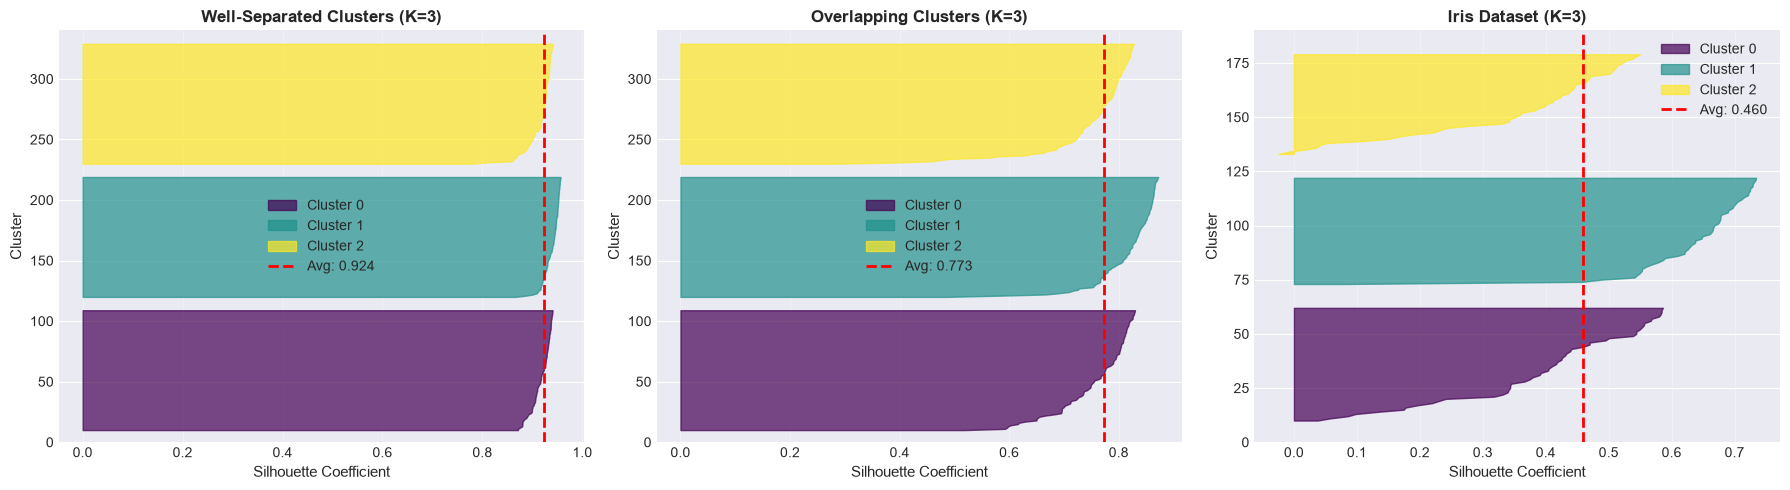

💡 Interpretation:
- Taller bars = larger clusters
- Red line = average silhouette score
- Bars extending left of red line = poorly assigned points
- Consistent bar height = balanced clusters


In [6]:
def plot_silhouette_diagram(X, labels, title, ax):
    """
    Create a silhouette diagram showing per-point silhouette coefficients.
    """
    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = silhouette_score(X, labels)
    
    y_lower = 10
    unique_labels = np.unique(labels)
    colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        cluster_silhouette_vals = silhouette_vals[labels == label]
        cluster_silhouette_vals.sort()
        
        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_silhouette_vals,
                         facecolor=colors[i], edgecolor=colors[i], alpha=0.7,
                         label=f'Cluster {label}')
        y_lower = y_upper + 10
    
    ax.axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=2,
               label=f'Avg: {silhouette_avg:.3f}')
    ax.set_xlabel('Silhouette Coefficient', fontsize=11)
    ax.set_ylabel('Cluster', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim([0, len(X) + (len(unique_labels) + 1) * 10])
    ax.grid(True, alpha=0.3, axis='x')
    ax.legend(loc='best')

# Create silhouette plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Well-separated
kmeans_well = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_well = kmeans_well.fit_predict(X_well_separated)
plot_silhouette_diagram(X_well_separated, labels_well, 
                       'Well-Separated Clusters (K=3)', axes[0])

# Overlapping
kmeans_overlap = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_overlap = kmeans_overlap.fit_predict(X_overlapping)
plot_silhouette_diagram(X_overlapping, labels_overlap,
                       'Overlapping Clusters (K=3)', axes[1])

# Iris
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_iris = kmeans_iris.fit_predict(X_iris)
plot_silhouette_diagram(X_iris, labels_iris,
                       'Iris Dataset (K=3)', axes[2])

plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("- Taller bars = larger clusters")
print("- Red line = average silhouette score")
print("- Bars extending left of red line = poorly assigned points")
print("- Consistent bar height = balanced clusters")

<a name="davies-bouldin"></a>
## Davies-Bouldin Index

### Intuition

The Davies-Bouldin (DB) index measures the average similarity between each cluster and its most similar other cluster. 

For each cluster $i$, we compute:
$$R_i = \max_{i \neq j} \frac{S_i + S_j}{d_{ij}}$$

Where:
- $S_i$ = average distance within cluster $i$ (compactness)
- $S_j$ = average distance within cluster $j$ 
- $d_{ij}$ = distance between cluster centers (separation)

The Davies-Bouldin Index is:
$$DB = \frac{1}{n_c} \sum_i R_i$$

Where $n_c$ is the number of clusters.

### Interpretation

- **Lower is better** (unlike silhouette)
- DB near 0: Excellent clustering (compact, well-separated clusters)
- DB > 1: Clusters may be overlapping or poorly defined

### Computing Davies-Bouldin from Scratch

In [7]:
def compute_davies_bouldin_from_scratch(X: NDArray, labels: NDArray) -> float:
    """
    Compute Davies-Bouldin index from scratch.
    """
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    # Compute cluster centers
    centers = np.array([X[labels == label].mean(axis=0) for label in unique_labels])
    
    # Compute average within-cluster distances (compactness)
    S = np.zeros(n_clusters)
    for i, label in enumerate(unique_labels):
        cluster_points = X[labels == label]
        center = centers[i]
        S[i] = np.mean([euclidean(point, center) for point in cluster_points])
    
    # Compute pairwise center distances
    center_distances = cdist(centers, centers, metric='euclidean')
    
    # Compute DB index
    R = np.zeros(n_clusters)
    for i in range(n_clusters):
        ratios = []
        for j in range(n_clusters):
            if i != j and center_distances[i, j] > 0:
                ratio = (S[i] + S[j]) / center_distances[i, j]
                ratios.append(ratio)
        if ratios:
            R[i] = max(ratios)
    
    db_index = np.mean(R)
    return db_index

# Test on well-separated data
db_scratch = compute_davies_bouldin_from_scratch(X_well_separated, labels_well)
db_sklearn = davies_bouldin_score(X_well_separated, labels_well)

print(f"Davies-Bouldin (from scratch): {db_scratch:.4f}")
print(f"Davies-Bouldin (sklearn):      {db_sklearn:.4f}")
print(f"Match: {np.isclose(db_scratch, db_sklearn)}")

Davies-Bouldin (from scratch): 0.1069
Davies-Bouldin (sklearn):      0.1069
Match: True


### Davies-Bouldin for Different K Values

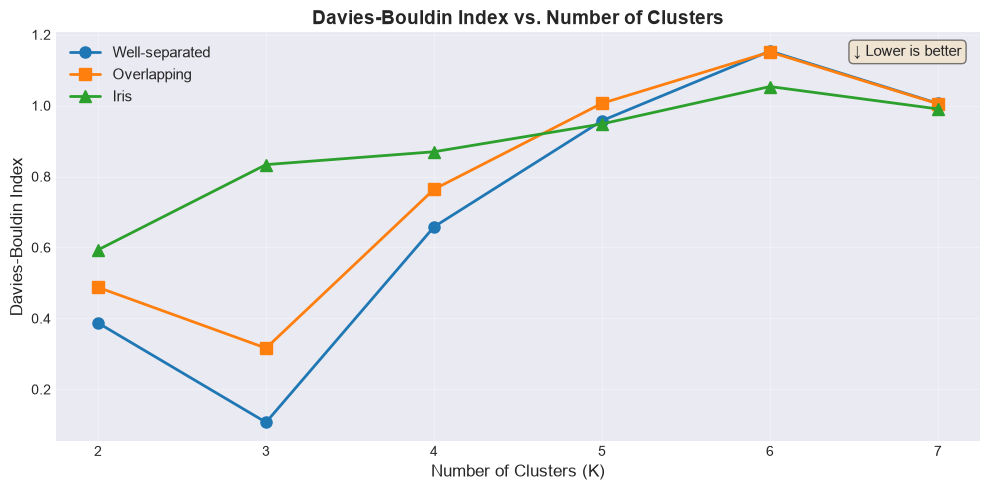

💡 Observations:
Well-separated: Minimum at K=3, DB=0.107
Overlapping: Minimum at K=3, DB=0.316 (higher than well-separated)
Iris: Minimum at K=2, DB=0.593


In [8]:
# Compute DB index for different K values
def compute_db_for_k_range(X, k_range):
    scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = davies_bouldin_score(X, labels)
        scores.append(score)
    return scores

k_range = range(2, 8)
db_well = compute_db_for_k_range(X_well_separated, k_range)
db_overlap = compute_db_for_k_range(X_overlapping, k_range)
db_iris = compute_db_for_k_range(X_iris, k_range)

# Plot Davies-Bouldin scores
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, db_well, 'o-', linewidth=2, markersize=8, label='Well-separated')
ax.plot(k_range, db_overlap, 's-', linewidth=2, markersize=8, label='Overlapping')
ax.plot(k_range, db_iris, '^-', linewidth=2, markersize=8, label='Iris')

ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Davies-Bouldin Index', fontsize=12)
ax.set_title('Davies-Bouldin Index vs. Number of Clusters', fontsize=14, fontweight='bold')
ax.set_xticks(k_range)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.text(0.98, 0.97, '↓ Lower is better', transform=ax.transAxes, 
        ha='right', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("💡 Observations:")
print(f"Well-separated: Minimum at K=3, DB={min(db_well):.3f}")
print(f"Overlapping: Minimum at K=3, DB={db_overlap[1]:.3f} (higher than well-separated)")
print(f"Iris: Minimum at K={k_range[np.argmin(db_iris)]}, DB={min(db_iris):.3f}")

<a name="calinski-harabasz"></a>
## Calinski-Harabasz Score

### Intuition

The Calinski-Harabasz score (also called Variance Ratio Criterion) measures the ratio of between-cluster dispersion to within-cluster dispersion.

$$CH = \frac{BCSS / (k - 1)}{WCSS / (n - k)}$$

Where:
- $BCSS$ = Between-Cluster Sum of Squares (how far clusters are from global center)
- $WCSS$ = Within-Cluster Sum of Squares (how tight clusters are)
- $k$ = number of clusters
- $n$ = number of samples

### Interpretation

- **Higher is better**
- CH near 0: Clusters are similar to global average (poorly separated)
- CH > 1: Better clustering (clusters are distinct from global center)
- This metric favors more clusters (inherent bias toward higher K)

### Computing Calinski-Harabasz from Scratch

In [9]:
def compute_calinski_harabasz_from_scratch(X: NDArray, labels: NDArray) -> float:
    """
    Compute Calinski-Harabasz score from scratch.
    """
    n_samples, n_features = X.shape
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    # Global center
    global_center = X.mean(axis=0)
    
    # Between-cluster sum of squares (BCSS)
    bcss = 0
    for label in unique_labels:
        cluster_points = X[labels == label]
        cluster_center = cluster_points.mean(axis=0)
        cluster_size = len(cluster_points)
        bcss += cluster_size * np.sum((cluster_center - global_center) ** 2)
    
    # Within-cluster sum of squares (WCSS)
    wcss = 0
    for label in unique_labels:
        cluster_points = X[labels == label]
        cluster_center = cluster_points.mean(axis=0)
        wcss += np.sum((cluster_points - cluster_center) ** 2)
    
    # Calinski-Harabasz score
    if n_clusters == 1 or wcss == 0:
        return 0
    
    ch_score = (bcss / (n_clusters - 1)) / (wcss / (n_samples - n_clusters))
    return ch_score

# Test on well-separated data
ch_scratch = compute_calinski_harabasz_from_scratch(X_well_separated, labels_well)
ch_sklearn = calinski_harabasz_score(X_well_separated, labels_well)

print(f"Calinski-Harabasz (from scratch): {ch_scratch:.4f}")
print(f"Calinski-Harabasz (sklearn):      {ch_sklearn:.4f}")
print(f"Match: {np.isclose(ch_scratch, ch_sklearn)}")

Calinski-Harabasz (from scratch): 20582.1557
Calinski-Harabasz (sklearn):      20582.1557
Match: True


### Calinski-Harabasz for Different K Values

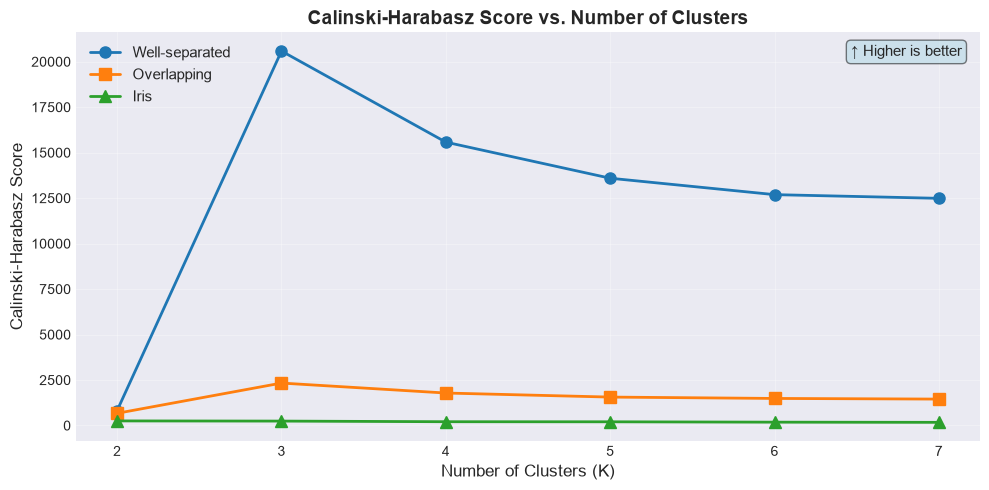

💡 Observations:
Well-separated: Generally high, peaks at K=3 (true clusters)
Overlapping: Lower scores overall (clusters less distinct)
Iris: CH score increases with K (metric favors more clusters)

⚠️  Warning: CH tends to favor higher K — use with other metrics!


In [10]:
# Compute CH score for different K values
def compute_ch_for_k_range(X, k_range):
    scores = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = calinski_harabasz_score(X, labels)
        scores.append(score)
    return scores

k_range = range(2, 8)
ch_well = compute_ch_for_k_range(X_well_separated, k_range)
ch_overlap = compute_ch_for_k_range(X_overlapping, k_range)
ch_iris = compute_ch_for_k_range(X_iris, k_range)

# Plot Calinski-Harabasz scores
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_range, ch_well, 'o-', linewidth=2, markersize=8, label='Well-separated')
ax.plot(k_range, ch_overlap, 's-', linewidth=2, markersize=8, label='Overlapping')
ax.plot(k_range, ch_iris, '^-', linewidth=2, markersize=8, label='Iris')

ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Calinski-Harabasz Score', fontsize=12)
ax.set_title('Calinski-Harabasz Score vs. Number of Clusters', fontsize=14, fontweight='bold')
ax.set_xticks(k_range)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.text(0.98, 0.97, '↑ Higher is better', transform=ax.transAxes,
        ha='right', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

print("💡 Observations:")
print(f"Well-separated: Generally high, peaks at K=3 (true clusters)")
print(f"Overlapping: Lower scores overall (clusters less distinct)")
print(f"Iris: CH score increases with K (metric favors more clusters)")
print("\n⚠️  Warning: CH tends to favor higher K — use with other metrics!")

<a name="external-metrics"></a>
## External Metrics: Comparing Clusterings When Labels Exist

External metrics compare two clusterings (assignments). They're useful when you have:
1. Partial ground-truth labels (some, but not all, points are labeled)
2. Two clustering results you want to compare
3. A candidate clustering you want to validate against known labels

**Key difference from internal metrics**: These REQUIRE a reference clustering (ground truth or another algorithm's output).

<a name="adjusted-rand"></a>
## Adjusted Rand Index (ARI)

### Intuition

The Adjusted Rand Index measures the agreement between two clusterings, corrected for random agreement.

Imagine flipping a coin for each pair of points: "Are they in the same cluster?" The ARI asks: **How much better is the agreement than random chance?**

### Formula

$$ARI = \frac{RI - E[RI]}{\max(RI) - E[RI]}$$

Where $RI$ (Rand Index) counts pairs of points that have the same relationship in both clusterings.

### Interpretation

- ARI = 1: Perfect agreement
- ARI = 0: Agreement no better than random
- ARI < 0: Agreement worse than random (negative agreement)

### Using ARI to Validate Clustering Against True Labels

In [11]:
# Run K-Means on Iris (forget the true labels for clustering)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
predicted_labels = kmeans.fit_predict(X_iris)

# Compare predicted clusters to true species labels
ari_score = adjusted_rand_score(y_iris, predicted_labels)

print(f"Adjusted Rand Index (Iris): {ari_score:.4f}")
print("\n💡 Interpretation:")
print(f"ARI = {ari_score:.3f} means the K-Means clustering has {ari_score*100:.1f}% agreement")
print("with the true iris species, adjusted for random chance.")

# Show confusion-like matrix
print("\nCluster assignments:")
df_ari = pd.DataFrame({'True Species': y_iris, 'Predicted Cluster': predicted_labels})
print(pd.crosstab(df_ari['True Species'], df_ari['Predicted Cluster'], margins=True))

Adjusted Rand Index (Iris): 0.6201

💡 Interpretation:
ARI = 0.620 means the K-Means clustering has 62.0% agreement
with the true iris species, adjusted for random chance.

Cluster assignments:
Predicted Cluster   0   1   2  All
True Species                      
0                   0  50   0   50
1                  39   0  11   50
2                  14   0  36   50
All                53  50  47  150


<a name="normalized-mi"></a>
## Normalized Mutual Information (NMI)

### Intuition

Normalized Mutual Information measures how much **information is shared** between two clusterings.

Think of it as: "If I tell you the true labels, how much does that reduce the uncertainty about the predicted labels?"

### Interpretation

- NMI = 1: Perfect agreement
- NMI = 0: Clusterings are independent (no information shared)
- NMI > 0.8: Good agreement
- NMI > 0.5: Moderate agreement

In [12]:
# Compare Normalized Mutual Information
nmi_score = normalized_mutual_info_score(y_iris, predicted_labels)

print(f"Normalized Mutual Information (Iris): {nmi_score:.4f}")
print(f"\nComparison:")
print(f"  ARI: {ari_score:.4f}")
print(f"  NMI: {nmi_score:.4f}")
print("\n💡 Both metrics show high agreement with true labels.")
print("This suggests K-Means found meaningful clusters in Iris.")

Normalized Mutual Information (Iris): 0.6595

Comparison:
  ARI: 0.6201
  NMI: 0.6595

💡 Both metrics show high agreement with true labels.
This suggests K-Means found meaningful clusters in Iris.


### Comparing Multiple Clustering Algorithms with External Metrics

Algorithm Comparison (vs. True Labels):
   Algorithm      ARI      NMI  Clusters
     K-Means 0.620135 0.659487         3
Hierarchical 0.615323 0.675470         3
      DBSCAN 0.551755 0.689979         3


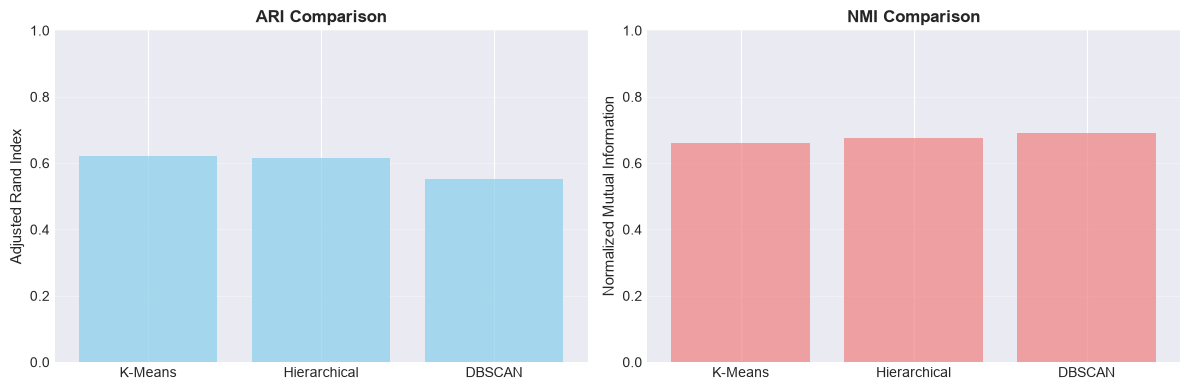

In [13]:
# Run different algorithms on Iris
from sklearn.cluster import AgglomerativeClustering, DBSCAN

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_iris)

# Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hierarchical = hierarchical.fit_predict(X_iris)

# DBSCAN (adaptive epsilon)
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_iris)

# Compare all algorithms
algorithms = ['K-Means', 'Hierarchical', 'DBSCAN']
predicted_labelss = [labels_kmeans, labels_hierarchical, labels_dbscan]

results = []
for algo, labels in zip(algorithms, predicted_labelss):
    if len(np.unique(labels)) > 1:  # Only if more than 1 cluster
        ari = adjusted_rand_score(y_iris, labels)
        nmi = normalized_mutual_info_score(y_iris, labels)
        results.append({'Algorithm': algo, 'ARI': ari, 'NMI': nmi, 'Clusters': len(np.unique(labels))})

results_df = pd.DataFrame(results)
print("Algorithm Comparison (vs. True Labels):")
print(results_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x_pos = np.arange(len(results_df))
ax = axes[0]
ax.bar(x_pos, results_df['ARI'], alpha=0.7, color='skyblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Algorithm'])
ax.set_ylabel('Adjusted Rand Index', fontsize=11)
ax.set_title('ARI Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.bar(x_pos, results_df['NMI'], alpha=0.7, color='lightcoral')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Algorithm'])
ax.set_ylabel('Normalized Mutual Information', fontsize=11)
ax.set_title('NMI Comparison', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

<a name="elbow-method"></a>
## Choosing K: The Elbow Method

### Intuition

As you increase the number of clusters $K$:
- **Inertia** (within-cluster sum of squares) always decreases
- At first, adding clusters helps a lot (big drop in inertia)
- Eventually, adding more clusters helps less and less
- The "elbow" point is where diminishing returns begin

This is an internal method — it works without labels.

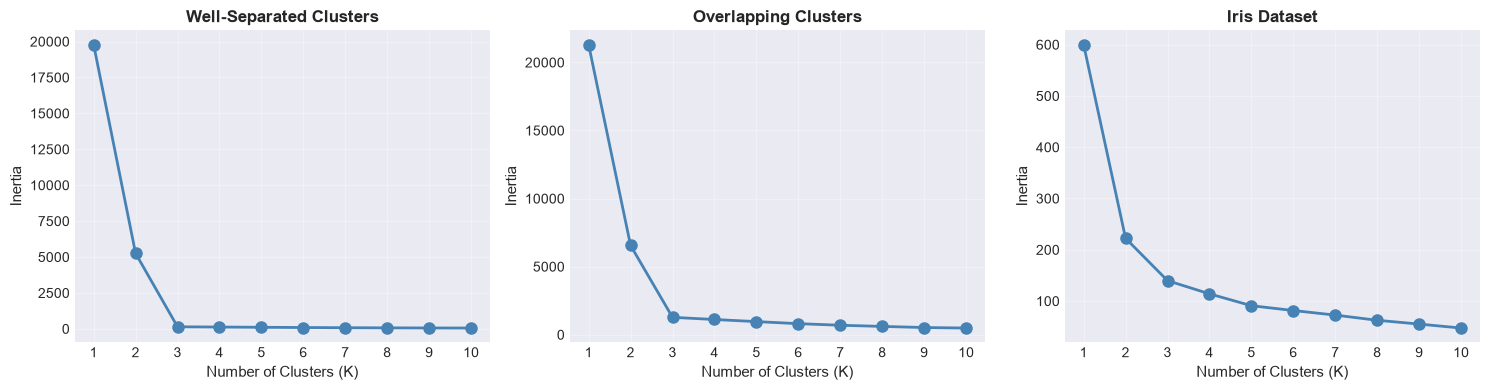

💡 Observation: The elbow point is subjective.
Well-separated: Clear elbow at K=3
Overlapping: Less clear elbow
Iris: Gradual decrease (less clear)


In [14]:
# Compute inertia for different K values
def compute_inertia_for_k_range(X, k_range):
    inertias = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
    return inertias

k_range = range(1, 11)
inertia_well = compute_inertia_for_k_range(X_well_separated, k_range)
inertia_overlap = compute_inertia_for_k_range(X_overlapping, k_range)
inertia_iris = compute_inertia_for_k_range(X_iris, k_range)

# Plot elbow method
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (inertias, title, ax) in enumerate([
    (inertia_well, 'Well-Separated Clusters', axes[0]),
    (inertia_overlap, 'Overlapping Clusters', axes[1]),
    (inertia_iris, 'Iris Dataset', axes[2])
]):
    ax.plot(k_range, inertias, 'o-', linewidth=2, markersize=8, color='steelblue')
    ax.set_xlabel('Number of Clusters (K)', fontsize=11)
    ax.set_ylabel('Inertia', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(k_range)

plt.tight_layout()
plt.show()

print("💡 Observation: The elbow point is subjective.")
print("Well-separated: Clear elbow at K=3")
print("Overlapping: Less clear elbow")
print("Iris: Gradual decrease (less clear)")

### Computing the Elbow Point Automatically

In [15]:
def find_elbow_point(inertias: list) -> int:
    """
    Find elbow point using the "knee" detection method.
    Returns the index K where the rate of inertia decrease slows.
    """
    # Compute second derivative (rate of change of rate of change)
    diffs = np.diff(inertias)
    diffs2 = np.diff(diffs)
    
    # Elbow is where second derivative is largest (steepest turn)
    elbow_idx = np.argmax(diffs2) + 1  # +1 accounts for diff reducing size
    return elbow_idx + 1  # +1 because K starts at 1, not 0

# Find elbow points
elbow_well = find_elbow_point(inertia_well)
elbow_overlap = find_elbow_point(inertia_overlap)
elbow_iris = find_elbow_point(inertia_iris)

print(f"Estimated elbow points:")
print(f"  Well-separated: K={elbow_well}")
print(f"  Overlapping: K={elbow_overlap}")
print(f"  Iris: K={elbow_iris}")

Estimated elbow points:
  Well-separated: K=2
  Overlapping: K=2
  Iris: K=2


<a name="gap-statistic"></a>
## Choosing K: The Gap Statistic

### Intuition

The gap statistic compares the real data to randomly generated data:
1. Cluster real data for each K
2. Cluster random uniform data for each K (using the same algorithm)
3. Compare inertia: how much better is the real data than random?
4. The "gap" is: real inertia vs. random inertia
5. Choose K where the gap is largest

### Why It Works

- If the data has natural clusters, real data should cluster much better than random data
- If K is too high, even random data will appear to cluster well
- The gap peaks at the true K

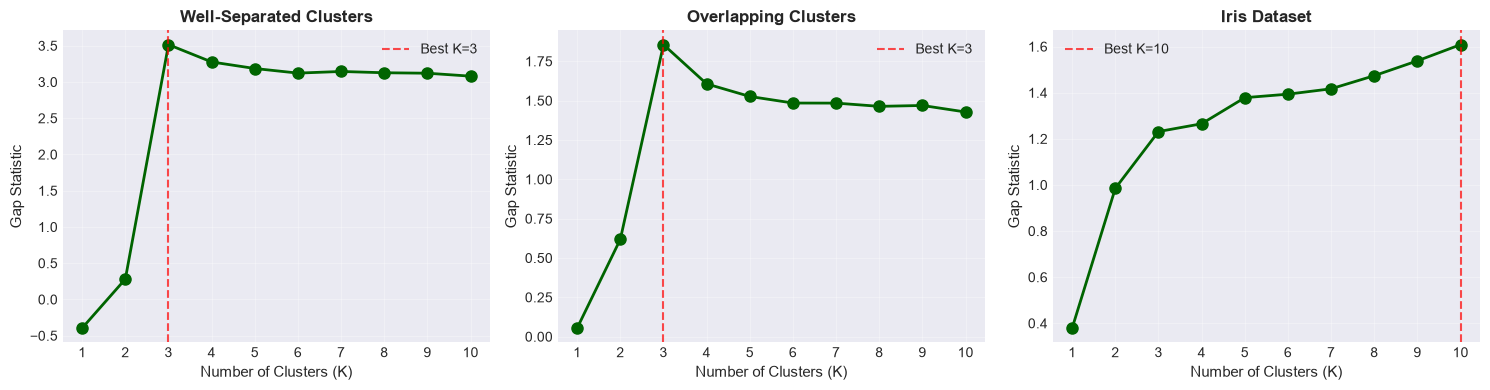

Gap Statistic Results:
  Well-separated: Best K=3
  Overlapping: Best K=3
  Iris: Best K=10


In [16]:
def compute_gap_statistic(X, k_range, n_refs=10, random_state=42):
    """
    Compute gap statistic.
    
    Args:
        X: Data array
        k_range: Range of K values to test
        n_refs: Number of random datasets to generate
        random_state: For reproducibility
    
    Returns:
        gaps: Gap statistic for each K
    """
    np.random.seed(random_state)
    
    real_inertias = []
    ref_inertias = []
    
    # Compute inertia on real data
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        kmeans.fit(X)
        real_inertias.append(np.log(kmeans.inertia_))
    
    # Compute inertia on random data
    ref_log_inertias_per_k = [[] for _ in range(len(k_range))]
    
    for _ in range(n_refs):
        # Generate random data with same shape and bounds as X
        X_random = np.random.uniform(
            X.min(axis=0), X.max(axis=0), size=X.shape
        )
        
        for i, k in enumerate(k_range):
            kmeans = KMeans(n_clusters=k, random_state=None, n_init=5)
            kmeans.fit(X_random)
            ref_log_inertias_per_k[i].append(np.log(kmeans.inertia_))
    
    # Average log inertias from reference data
    ref_inertias = [np.mean(ref_log_inertias_per_k[i]) for i in range(len(k_range))]
    
    # Gap = log(ref_inertia) - log(real_inertia)
    gaps = ref_inertias - np.array(real_inertias)
    
    return gaps

# Compute gap statistic
k_range = range(1, 11)
gaps_well = compute_gap_statistic(X_well_separated, k_range, n_refs=10)
gaps_overlap = compute_gap_statistic(X_overlapping, k_range, n_refs=10)
gaps_iris = compute_gap_statistic(X_iris, k_range, n_refs=10)

# Plot gap statistic
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (gaps, title, ax) in enumerate([
    (gaps_well, 'Well-Separated Clusters', axes[0]),
    (gaps_overlap, 'Overlapping Clusters', axes[1]),
    (gaps_iris, 'Iris Dataset', axes[2])
]):
    k_vals = list(k_range)
    best_k = k_vals[np.argmax(gaps)]
    
    ax.plot(k_vals, gaps, 'o-', linewidth=2, markersize=8, color='darkgreen')
    ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K={best_k}')
    ax.set_xlabel('Number of Clusters (K)', fontsize=11)
    ax.set_ylabel('Gap Statistic', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(k_vals)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Gap Statistic Results:")
print(f"  Well-separated: Best K={list(k_range)[np.argmax(gaps_well)]}")
print(f"  Overlapping: Best K={list(k_range)[np.argmax(gaps_overlap)]}")
print(f"  Iris: Best K={list(k_range)[np.argmax(gaps_iris)]}")

<a name="visual-evaluation"></a>
## Visual Evaluation Techniques

No metric tells the whole story. **Always visualize your clusters.**

### 2D Projection with Cluster Coloring

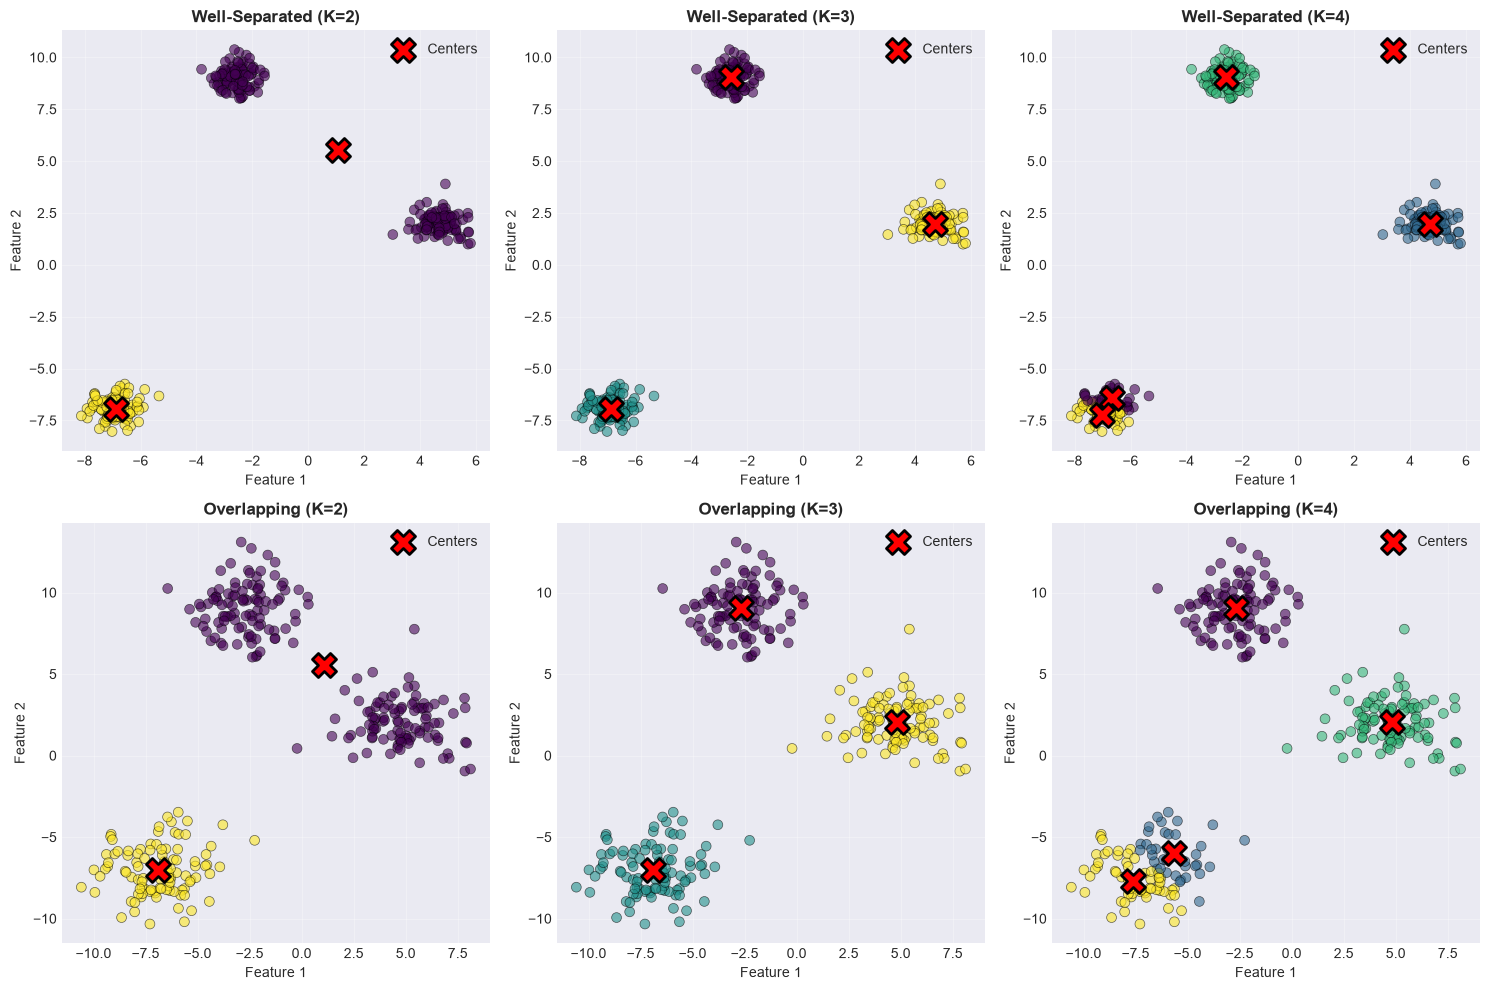

💡 Observations:
Well-separated: Clear clusters at K=3, harder to justify more
Overlapping: Clusters blend together regardless of K
Visual inspection often catches what metrics miss!


In [17]:
# Cluster different datasets and visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Well-separated: Test different K values
k_values = [2, 3, 4]
for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_well_separated)
    
    ax = axes[0, idx]
    scatter = ax.scatter(X_well_separated[:, 0], X_well_separated[:, 1],
                         c=labels, cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
              c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centers')
    ax.set_title(f'Well-Separated (K={k})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Overlapping: Test different K values
for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_overlapping)
    
    ax = axes[1, idx]
    scatter = ax.scatter(X_overlapping[:, 0], X_overlapping[:, 1],
                         c=labels, cmap='viridis', alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
              c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centers')
    ax.set_title(f'Overlapping (K={k})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("💡 Observations:")
print("Well-separated: Clear clusters at K=3, harder to justify more")
print("Overlapping: Clusters blend together regardless of K")
print("Visual inspection often catches what metrics miss!")

### Cluster Characteristics: Size and Distance Distribution

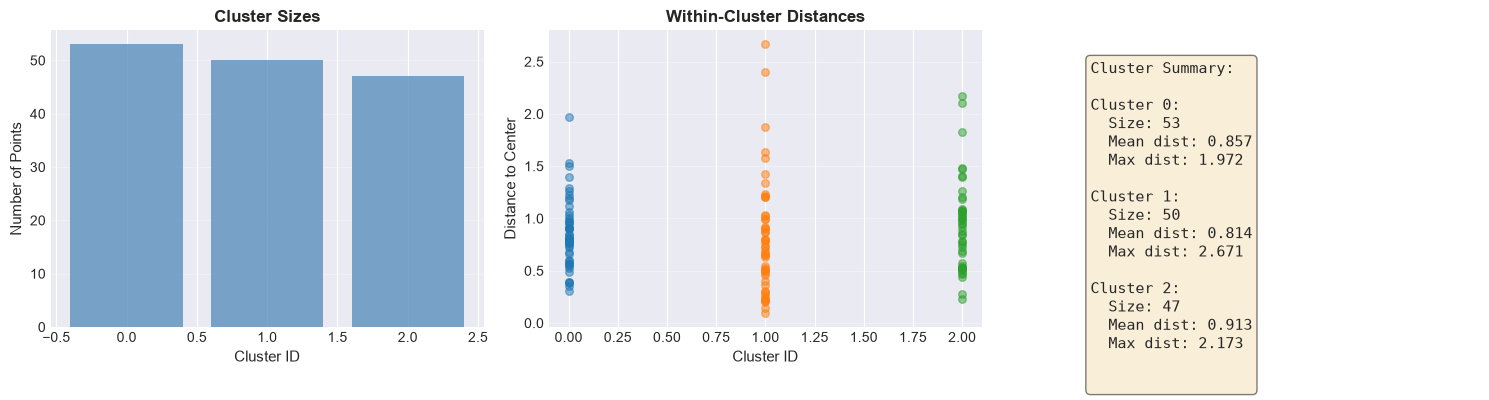

In [18]:
# Analyze cluster characteristics
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_iris = kmeans_iris.fit_predict(X_iris)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cluster sizes
ax = axes[0]
cluster_sizes = np.bincount(labels_iris)
ax.bar(range(len(cluster_sizes)), cluster_sizes, color='steelblue', alpha=0.7)
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Number of Points', fontsize=11)
ax.set_title('Cluster Sizes', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Distance to cluster center
ax = axes[1]
distances_to_centers = []
for i in range(3):
    cluster_mask = labels_iris == i
    cluster_points = X_iris[cluster_mask]
    center = kmeans_iris.cluster_centers_[i]
    dists = np.linalg.norm(cluster_points - center, axis=1)
    distances_to_centers.extend(dists)
    ax.scatter([i] * len(dists), dists, alpha=0.5, s=30)

ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('Distance to Center', fontsize=11)
ax.set_title('Within-Cluster Distances', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Summary statistics
ax = axes[2]
ax.axis('off')

summary_text = "Cluster Summary:\n\n"
for i in range(3):
    cluster_mask = labels_iris == i
    cluster_points = X_iris[cluster_mask]
    center = kmeans_iris.cluster_centers_[i]
    dists = np.linalg.norm(cluster_points - center, axis=1)
    
    summary_text += f"Cluster {i}:\n"
    summary_text += f"  Size: {cluster_sizes[i]}\n"
    summary_text += f"  Mean dist: {dists.mean():.3f}\n"
    summary_text += f"  Max dist: {dists.max():.3f}\n\n"

ax.text(0.1, 0.9, summary_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

<a name="workflow"></a>
## Putting It Together: Complete Evaluation Workflow

Here's how to evaluate clusters in practice:

In [19]:
def comprehensive_cluster_evaluation(X, k_range=range(2, 8), title="Dataset"):
    """
    Comprehensive evaluation of clustering across multiple K values and metrics.
    """
    results = []
    
    print(f"\n{'='*60}")
    print(f"Comprehensive Evaluation: {title}")
    print(f"{'='*60}")
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        # Compute metrics
        silhouette = silhouette_score(X, labels)
        davies_bouldin = davies_bouldin_score(X, labels)
        calinski = calinski_harabasz_score(X, labels)
        inertia = kmeans.inertia_
        
        results.append({
            'K': k,
            'Silhouette': silhouette,
            'Davies-Bouldin': davies_bouldin,
            'Calinski-Harabasz': calinski,
            'Inertia': inertia
        })
    
    df = pd.DataFrame(results)
    
    # Find optimal K by each metric
    best_silhouette_k = df.loc[df['Silhouette'].idxmax(), 'K']
    best_davies_k = df.loc[df['Davies-Bouldin'].idxmin(), 'K']
    best_calinski_k = df.loc[df['Calinski-Harabasz'].idxmax(), 'K']
    
    print("\nMetric Scores:")
    print(df.to_string(index=False))
    
    print(f"\n{'Recommended K values:':40} {'':<20}")
    print(f"  By Silhouette:        K={int(best_silhouette_k):2d}  (score={df.loc[df['Silhouette'].idxmax(), 'Silhouette']:.3f})")
    print(f"  By Davies-Bouldin:    K={int(best_davies_k):2d}  (score={df.loc[df['Davies-Bouldin'].idxmin(), 'Davies-Bouldin']:.3f})")
    print(f"  By Calinski-Harabasz: K={int(best_calinski_k):2d}  (score={df.loc[df['Calinski-Harabasz'].idxmax(), 'Calinski-Harabasz']:.1f})")
    
    return df

# Evaluate all datasets
df_well = comprehensive_cluster_evaluation(X_well_separated, title="Well-Separated Clusters")
df_overlap = comprehensive_cluster_evaluation(X_overlapping, title="Overlapping Clusters")
df_iris = comprehensive_cluster_evaluation(X_iris, title="Iris Dataset")


Comprehensive Evaluation: Well-Separated Clusters

Metric Scores:
 K  Silhouette  Davies-Bouldin  Calinski-Harabasz     Inertia
 2    0.743887        0.387180         823.554904 5256.513541
 3    0.923561        0.106948       20582.155687  141.714888
 4    0.721344        0.658218       15575.021092  124.537840
 5    0.520826        0.957491       13591.492172  106.782163
 6    0.326840        1.153773       12689.441766   91.249207
 7    0.357272        1.005992       12486.746610   77.067984

Recommended K values:                                        
  By Silhouette:        K= 3  (score=0.924)
  By Davies-Bouldin:    K= 3  (score=0.107)
  By Calinski-Harabasz: K= 3  (score=20582.2)

Comprehensive Evaluation: Overlapping Clusters

Metric Scores:
 K  Silhouette  Davies-Bouldin  Calinski-Harabasz     Inertia
 2    0.665444        0.487532         670.603856 6555.184495
 3    0.773421        0.316125        2332.251806 1275.433990
 4    0.608533        0.764032        1784.350938 11


Metric Scores:
 K  Silhouette  Davies-Bouldin  Calinski-Harabasz    Inertia
 2    0.581750        0.593313         251.349339 222.361705
 3    0.459948        0.833595         241.904402 139.820496
 4    0.386941        0.869814         207.265914 114.092547
 5    0.345901        0.948317         202.951525  90.927514
 6    0.317079        1.053677         183.109118  81.544391
 7    0.320197        0.990528         173.051904  72.631144

Recommended K values:                                        
  By Silhouette:        K= 2  (score=0.582)
  By Davies-Bouldin:    K= 2  (score=0.593)
  By Calinski-Harabasz: K= 2  (score=251.3)


### Decision Framework

In [20]:
print("""
📊 DECISION FRAMEWORK FOR CHOOSING K

1. START WITH MULTIPLE METRICS
   ✓ Silhouette:        High values (>0.5) indicate good clustering
   ✓ Davies-Bouldin:    Low values (<1) indicate good clustering
   ✓ Calinski-Harabasz: High values indicate distinct clusters (biased toward high K)
   ✓ Elbow Method:      Look for where inertia decrease slows
   ✓ Gap Statistic:     Choose K where gap is largest

2. LOOK FOR CONSENSUS
   - If multiple metrics agree on K, that's strong evidence
   - If they disagree, consider domain knowledge

3. VISUALIZE
   - Plot clusters in 2D/3D projections
   - Check for:
     * Clear separation between clusters
     * Reasonable cluster sizes (not too many singletons)
     * No obvious misclassifications

4. VALIDATE EXTERNALLY (IF POSSIBLE)
   - If you have partial labels, use ARI or NMI
   - Compare against domain expert expectations
   - Check if clusters are interpretable

5. CHECK STABILITY
   - Run clustering multiple times with different random seeds
   - Stable K should produce similar clusters each time
""")


📊 DECISION FRAMEWORK FOR CHOOSING K

1. START WITH MULTIPLE METRICS
   ✓ Silhouette:        High values (>0.5) indicate good clustering
   ✓ Davies-Bouldin:    Low values (<1) indicate good clustering
   ✓ Calinski-Harabasz: High values indicate distinct clusters (biased toward high K)
   ✓ Elbow Method:      Look for where inertia decrease slows
   ✓ Gap Statistic:     Choose K where gap is largest

2. LOOK FOR CONSENSUS
   - If multiple metrics agree on K, that's strong evidence
   - If they disagree, consider domain knowledge

3. VISUALIZE
   - Plot clusters in 2D/3D projections
   - Check for:
     * Clear separation between clusters
     * Reasonable cluster sizes (not too many singletons)
     * No obvious misclassifications

4. VALIDATE EXTERNALLY (IF POSSIBLE)
   - If you have partial labels, use ARI or NMI
   - Compare against domain expert expectations
   - Check if clusters are interpretable

5. CHECK STABILITY
   - Run clustering multiple times with different random seeds


<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **Internal Metrics** evaluate clusters without labels:
   - **Silhouette**: Measures both cohesion and separation (intuitive, range -1 to +1)
   - **Davies-Bouldin**: Compares compactness to separation (lower is better)
   - **Calinski-Harabasz**: Between-cluster vs. within-cluster variance (higher is better, biased toward high K)

2. **External Metrics** compare clusterings when labels exist:
   - **Adjusted Rand Index**: Pairwise agreement corrected for chance
   - **Normalized Mutual Information**: Information shared between clusterings

3. **Choosing K**:
   - **Elbow Method**: Simple, intuitive, but subjective
   - **Gap Statistic**: More principled, compares real to random data
   - **Multiple metrics**: No single metric is definitive

4. **Visual Evaluation**:
   - Always plot clusters
   - Check cluster sizes, shapes, and separation
   - Verify interpretability in your domain

### The Gold Standard Process

1. Run multiple K values through all metrics
2. Identify K values recommended by silhouette, DB, and elbow
3. Visualize clusters at those K values
4. Choose K that makes sense for your domain
5. Check stability with multiple random initializations

### Next Steps

Now that you can evaluate clusters, you're ready for:
- **K-Means** (Lesson 1): The most popular clustering algorithm
- **DBSCAN** (Lesson 2): For discovering arbitrary cluster shapes
- **Hierarchical Clustering** (Lesson 3): Building dendrograms and understanding cluster hierarchies
- **Advanced topics**: Mixture models, spectral clustering, and density-based methods

Remember: **No algorithm finds clusters if they don't exist.** Good evaluation metrics protect you from finding false structure in noise.